### Random Forest

#### Árbol de regresión

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestRegressor
from ydata_profiling import ProfileReport

In [2]:
df = pd.read_csv("ToyotaCorolla.csv")

car_df = df[['price', 'age_08_04', 'km', 'fuel_type',
             'hp', 'met_color', 'automatic', 'cc', 'doors',
             'quarterly_tax', 'weight']].copy()

print(car_df.info())
car_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   price          1436 non-null   int64 
 1   age_08_04      1436 non-null   int64 
 2   km             1436 non-null   int64 
 3   fuel_type      1436 non-null   object
 4   hp             1436 non-null   int64 
 5   met_color      1436 non-null   int64 
 6   automatic      1436 non-null   int64 
 7   cc             1436 non-null   int64 
 8   doors          1436 non-null   int64 
 9   quarterly_tax  1436 non-null   int64 
 10  weight         1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB
None


,price,age_08_04,km,fuel_type,hp,met_color,automatic,cc,doors,quarterly_tax,weight
0,13500,23,46986,Diesel,90,1,0,2000,3,210,1165
1,13750,23,72937,Diesel,90,1,0,2000,3,210,1165
2,13950,24,41711,Diesel,90,1,0,2000,3,210,1165
3,14950,26,48000,Diesel,90,0,0,2000,3,210,1165
4,13750,30,38500,Diesel,90,0,0,2000,3,210,1170


In [5]:
# Realiza un reporte automatizado utilizando ydata-profiling para conocer mejor el dataset. 
profile = ProfileReport(car_df, title="Toyota Corolla Dataset Report")
profile.to_file("toyota_corolla_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 104.10it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [3]:
# Eliminamos los duplicados
car_df = car_df.drop_duplicates()
# Transformamos la variable fuel_type en variables dicotómicas con ceros y unos
car_df = pd.get_dummies(
    car_df,
    columns=['fuel_type'],
    drop_first=True,
    dtype=int
)
car_df.head()

,price,age_08_04,km,hp,met_color,automatic,cc,doors,quarterly_tax,weight,fuel_type_Diesel,fuel_type_Petrol
0,13500,23,46986,90,1,0,2000,3,210,1165,1,0
1,13750,23,72937,90,1,0,2000,3,210,1165,1,0
2,13950,24,41711,90,1,0,2000,3,210,1165,1,0
3,14950,26,48000,90,0,0,2000,3,210,1165,1,0
4,13750,30,38500,90,0,0,2000,3,210,1170,1,0


In [4]:
X = car_df.drop(columns="price")
y = car_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1148, 11), (287, 11), (1148,), (287,))

In [5]:
# Aplicamos wenserización para tratar los outliers conjunto de entrenamiento
for col in ['age_08_04', 'km', 'hp', 'cc', 'quarterly_tax', 'weight']:
    X_train[col] = X_train[col].clip(lower=X_train[col].quantile(0.01), upper=X_train[col].quantile(0.99))
# Aplicamos wenserización para tratar los outliers de price
y_train = y_train.clip(lower=y_train.quantile(0.01), upper=y_train.quantile(0.99))

/tmp/ipykernel_7893/1200874144.py:3: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[col] = X_train[col].clip(lower=X_train[col].quantile(0.01), upper=X_train[col].quantile(0.99))


In [6]:
# Duplicados en X_train
duplicados_X_train = X_train.duplicated().sum()
print(f"Número de filas duplicadas en X_train: {duplicados_X_train}")
# Borramos los duplicados en X_train
X_train = X_train.drop_duplicates()
y_train = y_train.loc[X_train.index]  # Aseguramos que y_train se alinee con X_train después de eliminar duplicados
print(f"Número de filas después de eliminar duplicados en X_train: {X_train.shape[0]}")

Número de filas duplicadas en X_train: 2
Número de filas después de eliminar duplicados en X_train: 1146


In [7]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

baseline_model = DecisionTreeRegressor(random_state=42)
baseline_model.fit(X_train, y_train)

y_pred_test = baseline_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"BASELINE (Test) -> RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f}")

BASELINE (Test) -> RMSE: 1412.30 | MAE: 1047.81 | R2: 0.8337


In [8]:
%matplotlib inline

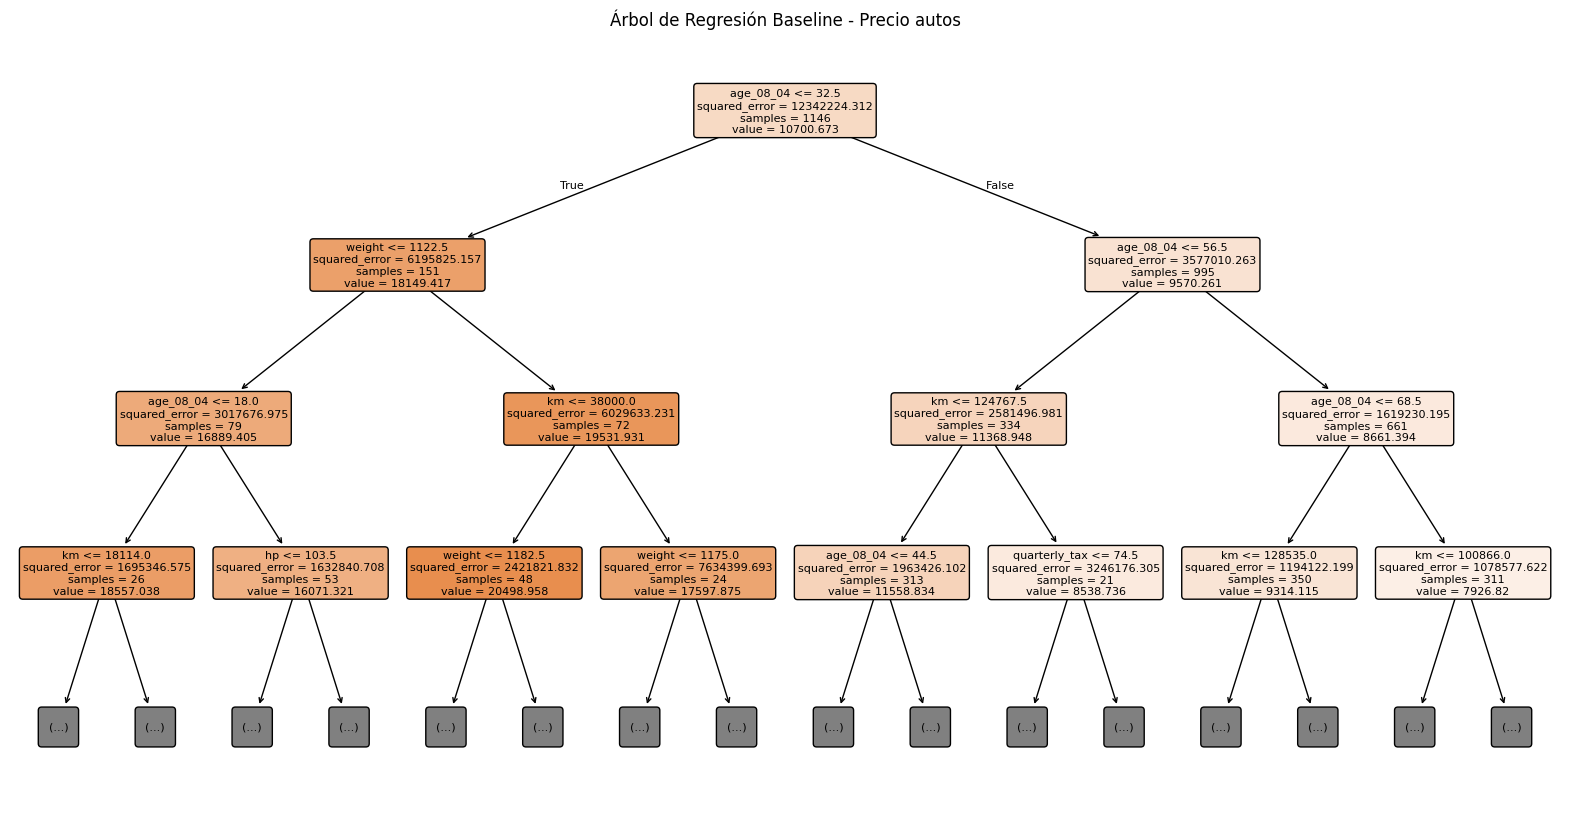

In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names = X_train.columns

plt.figure(figsize=(20,10))
plot_tree(
    baseline_model,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title("Árbol de Regresión Baseline - Precio autos")
plt.show()

In [10]:
path = baseline_model.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas
ccp_alphas = np.unique(ccp_alphas)

print("Cantidad de ccp_alphas:", len(ccp_alphas))
print("Primeros valores:", ccp_alphas[:10])

Cantidad de ccp_alphas: 608
Primeros valores: [0.00000000e+00 1.95041377e-11 7.27166957e-03 1.09075044e-02
 4.36300175e-02 2.72687609e-01 3.92670157e-01 6.98080279e-01
 8.83507853e-01 1.09075044e+00]


In [11]:
best_mae = float("inf")
best_params = None
best_model = None

for alpha in ccp_alphas:
    for leaf in [1, 3, 5, 10]:
        for depth in [None, 3, 5, 8, 12]:

            model = DecisionTreeRegressor(
                random_state=42,
                ccp_alpha=alpha,
                min_samples_leaf=leaf,
                max_depth=depth
            )

            model.fit(X_train, y_train)
            y_pred_train = model.predict(X_train)

            mae = mean_absolute_error(y_train, y_pred_train)

            if mae < best_mae:
                best_mae = mae
                best_params = {
                    "ccp_alpha": alpha,
                    "min_samples_leaf": leaf,
                    "max_depth": depth
                }
                best_model = model

print("Mejores hiperparámetros:", best_params)
print("Mejor MAE (Train):", best_mae)

Mejores hiperparámetros: {'ccp_alpha': np.float64(0.0), 'min_samples_leaf': 1, 'max_depth': None}
Mejor MAE (Train): 0.0


In [12]:
y_pred_test = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"MODELO FINAL (Test) -> RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f}")

MODELO FINAL (Test) -> RMSE: 1412.30 | MAE: 1047.81 | R2: 0.8337


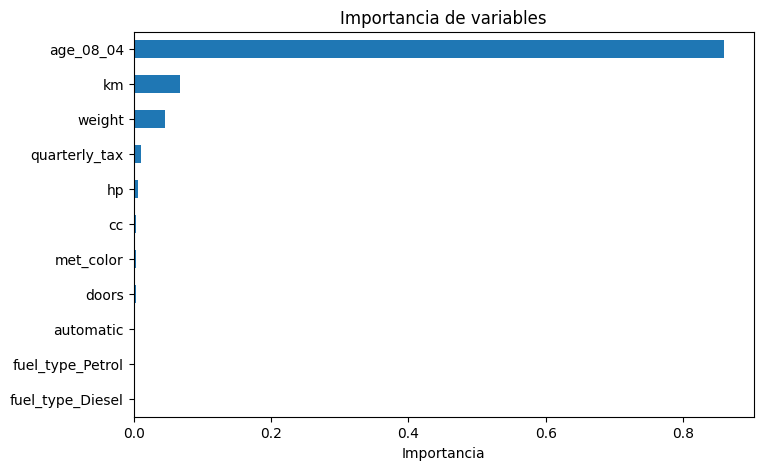

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.Series(best_model.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(8,5))
importancias.plot(kind='barh')
plt.title("Importancia de variables")
plt.xlabel("Importancia")
plt.show()

In [14]:
# Identificar la hoja donde cae cada cliente
leaf_id = best_model.apply(X_train)

# Crear dataset con el grupo asignado
clientes_segmentados = X_train.copy()
clientes_segmentados["grupo_arbol"] = leaf_id
clientes_segmentados["credito_real"] = y_train

clientes_segmentados.head()

,age_08_04,km,hp,met_color,automatic,cc,doors,quarterly_tax,weight,fuel_type_Diesel,fuel_type_Petrol,grupo_arbol,credito_real
1128,78,109263.0,110,0,0,1600,5,85,1070,0,1,1998,7500.0
899,62,59295.0,86,0,0,1300,5,69,1035,0,1,1045,9500.0
1188,71,90370.0,86,1,0,1300,5,69,1035,0,1,1626,7950.0
311,44,38461.0,110,1,0,1600,5,85,1080,0,1,442,13995.0
1145,75,101855.0,110,1,0,1600,5,85,1070,0,1,1974,6450.0


In [18]:
segmentos = clientes_segmentados.groupby("grupo_arbol").mean()
segmentos

,age_08_04,km,hp,met_color,automatic,cc,doors,quarterly_tax,weight,fuel_type_Diesel,fuel_type_Petrol,credito_real
grupo_arbol,,,,,,,,,,,,
7,8.0,4470.000,98.0,1.0,0.0,1400.0,4.0,19.0,1100.0,0.0,1.0,17795.00
8,15.0,13157.000,97.0,1.0,0.0,1400.0,4.0,85.0,1085.0,0.0,1.0,16868.00
12,8.0,4470.000,110.0,0.0,0.0,1600.0,5.0,19.0,1075.0,0.0,1.0,18500.00
13,9.0,4470.000,110.0,1.0,0.0,1600.0,5.0,19.0,1075.0,0.0,1.0,18245.00
14,14.0,11500.000,110.0,1.0,0.0,1600.0,3.0,69.0,1045.0,0.0,1.0,18800.00
...,...,...,...,...,...,...,...,...,...,...,...,...
2043,74.0,193170.250,72.0,1.0,0.0,2000.0,3.0,64.0,1135.0,1.0,0.0,5821.15
2044,78.0,193170.250,72.0,1.0,0.0,2000.0,5.0,185.0,1135.0,1.0,0.0,6000.00
2045,80.0,193170.250,72.0,0.0,0.0,2000.0,3.0,185.0,1120.0,1.0,0.0,6150.00


#### Random Forest

In [15]:
# Aplicamos el de random forest al conjunto de entrenamiento
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [16]:
# Predicción en el conjunto de prueba
y_pred_test = rf_model.predict(X_test)

In [17]:
# Evaluación del modelo de Random Forest
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"RANDOM FOREST BASE (Test) -> RMSE: {rmse:.2f}")
print(f"RANDOM FOREST BASE (Test) -> MAE: {mae:.2f}")
print(f"RANDOM FOREST BASE (Test) -> R2: {r2:.4f}")

RANDOM FOREST BASE (Test) -> RMSE: 1207.36
RANDOM FOREST BASE (Test) -> MAE: 841.75
RANDOM FOREST BASE (Test) -> R2: 0.8785


In [18]:
# Importancia de variables en Random Forest
importancias = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False)

print(importancias)

age_08_04           0.861892
km                  0.058006
weight              0.042638
hp                  0.014488
quarterly_tax       0.007289
met_color           0.004814
cc                  0.004014
doors               0.003503
fuel_type_Diesel    0.001315
fuel_type_Petrol    0.001177
automatic           0.000865
dtype: float64


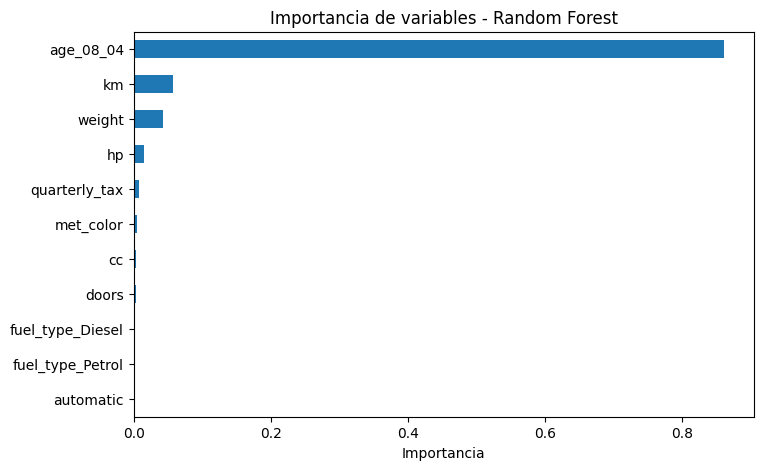

In [19]:
# Grafica de importancia de variables en Random Forest
plt.figure(figsize=(8,5))
importancias.sort_values().plot(kind='barh')
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.show()

In [20]:
# Validación cruzada para Random Forest
cv = KFold(n_splits=5, shuffle=True, random_state=42)

mae_cv = -cross_val_score(
    rf_model,
    X_train,
    y_train,
    scoring='neg_mean_absolute_error',
    cv=cv,
    n_jobs=-1
)

rmse_cv = np.sqrt(
    -cross_val_score(
        rf_model,
        X_train,
        y_train,
        scoring='neg_mean_squared_error',
        cv=cv,
        n_jobs=-1
    )
)

r2_cv = cross_val_score(
    rf_model,
    X_train,
    y_train,
    scoring='r2',
    cv=cv,
    n_jobs=-1
)

print("MAE por fold:", np.round(mae_cv, 2))
print("MAE promedio:", np.mean(mae_cv).round(2))

print("\nRMSE por fold:", np.round(rmse_cv, 2))
print("RMSE promedio:", np.mean(rmse_cv).round(2))

print("\nR2 por fold:", np.round(r2_cv, 4))
print("R2 promedio:", np.mean(r2_cv).round(4))

MAE por fold: [806.78 822.79 789.09 762.17 820.28]
MAE promedio: 800.22

RMSE por fold: [1009.3  1054.65 1076.08  999.54 1021.22]
RMSE promedio: 1032.16

R2 por fold: [0.9092 0.9107 0.9244 0.8978 0.9192]
R2 promedio: 0.9122


In [21]:
# Ajustar un modelo mejorado de Random Forest con hiperparámetros optimizados
rf_model2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42
)

rf_model2.fit(X_train, y_train)

y_pred_test_2 = rf_model2.predict(X_test)

In [22]:
# Evaluación del modelo mejorado
mse2 = mean_squared_error(y_test, y_pred_test_2)
rmse2 = np.sqrt(mse2)
mae2 = mean_absolute_error(y_test, y_pred_test_2)
r22 = r2_score(y_test, y_pred_test_2)

print(f"RANDOM FOREST AJUSTADO (Test) -> RMSE: {rmse2:.2f}")
print(f"RANDOM FOREST AJUSTADO (Test) -> MAE: {mae2:.2f}")
print(f"RANDOM FOREST AJUSTADO (Test) -> R2: {r22:.4f}")

RANDOM FOREST AJUSTADO (Test) -> RMSE: 1175.52
RANDOM FOREST AJUSTADO (Test) -> MAE: 803.99
RANDOM FOREST AJUSTADO (Test) -> R2: 0.8848


In [23]:
# Comparación entre modelos
comparacion = pd.DataFrame({
    "Modelo": ["Random Forest Base", "Random Forest Ajustado"],
    "RMSE": [rmse, rmse2],
    "MAE": [mae, mae2],
    "R2": [r2, r22]
})

comparacion

,Modelo,RMSE,MAE,R2
0,Random Forest Base,1207.357986,841.746807,0.878495
1,Random Forest Ajustado,1175.515419,803.985410,0.884819


In [24]:
print("Interpretación sugerida:")
print("- Un menor RMSE y MAE indica que el modelo comete errores más pequeños.")
print("- Un mayor R2 indica que el modelo explica una mayor proporción de la variación del crédito aprobado.")
print("- Si el modelo ajustado mejora respecto al base, entonces la configuración de hiperparámetros ayudó a generalizar mejor.")

Interpretación sugerida:
- Un menor RMSE y MAE indica que el modelo comete errores más pequeños.
- Un mayor R2 indica que el modelo explica una mayor proporción de la variación del crédito aprobado.
- Si el modelo ajustado mejora respecto al base, entonces la configuración de hiperparámetros ayudó a generalizar mejor.
